C:\Users\DELL\AppData\Local\Temp\ipykernel_16488\470698054.py:75: DtypeWarning: Columns (188) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath)  # 加载完整的数据


DBSCAN labels: [-1  0  1]


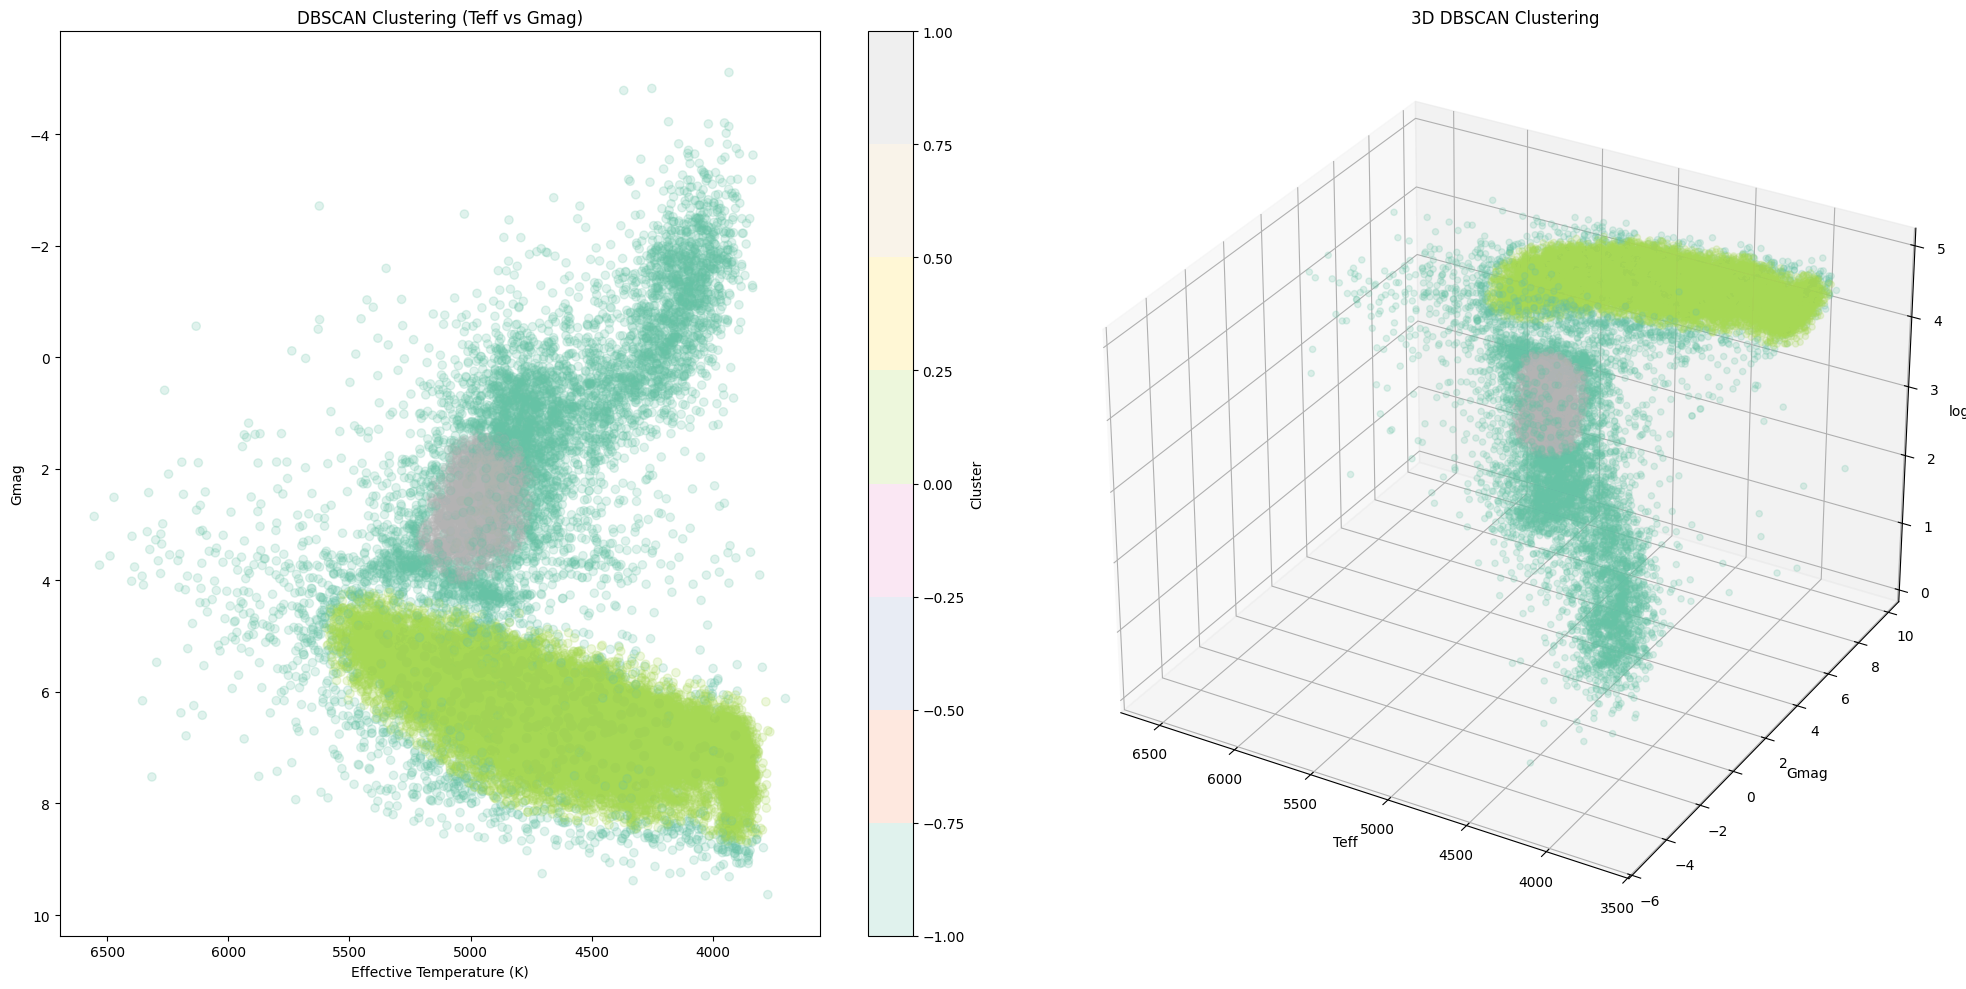

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  # 设置OpenMP线程数为1，避免并行计算问题

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from mpl_toolkits.mplot3d import Axes3D

# 1. 数据加载与预处理
def load_and_preprocess(filepath):
    df = pd.read_csv(filepath)
    # 打印列名以确保没有问题
    print("Columns:", df.columns)
    
    # 选择关键物理参数
    features = ['teff', 'GMAG', 'logg']  # 确保这些列名正确
    df = df[features].dropna()
    
    # 物理范围过滤
    df = df[(df['teff'] > 2500) & (df['teff'] < 50000)]  # 合理温度范围
    # 打印数据的前几行，检查数据是否加载正确
    print(df.head())
    
    return df

# 2. 数据标准化
def standardize_data(df):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df)
    return X_scaled, scaler

# 3. 聚类分析
def perform_clustering(X_scaled):
    # DBSCAN聚类
    dbscan = DBSCAN(eps=0.3, min_samples=300)  # 可根据实际情况调整参数
    dbscan_labels = dbscan.fit_predict(X_scaled)
    
    print("DBSCAN labels:", np.unique(dbscan_labels))  # 打印DBSCAN标签，查看噪声点(-1)
    
    return dbscan_labels

# 4. 可视化函数
def plot_cluster_results(df, X_scaled, dbscan_labels):
    # 创建画布
    plt.figure(figsize=(20, 10))
    
    # 二维图 - DBSCAN结果
    plt.subplot(121)
    scatter = plt.scatter(df['teff'], df['GMAG'], c=dbscan_labels, cmap='Set2', alpha=0.2)
    plt.title('DBSCAN Clustering (Teff vs Gmag)')
    plt.xlabel('Effective Temperature (K)')
    plt.ylabel('Gmag')
    plt.colorbar(scatter, label='Cluster')
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    
    # 三维图 - DBSCAN
    ax = plt.subplot(122, projection='3d')
    scatter = ax.scatter(df['teff'], df['GMAG'], df['logg'], 
                        c=dbscan_labels, cmap='Set2', alpha=0.2)
    ax.set_xlabel('Teff')
    ax.set_ylabel('Gmag')
    ax.set_zlabel('logg')
    plt.title('3D DBSCAN Clustering')
    plt.gca().invert_xaxis()
    plt.tight_layout()
    plt.savefig('K1.png', dpi=300)  # 修改保存文件名
    plt.show()

# 主流程
def main(filepath):
    # 1. 加载数据
    df = pd.read_csv(filepath)  # 加载完整的数据
    df_features = df[['teff', 'GMAG', 'logg']].dropna()  # 仅对关键特征进行操作
    df_features = df_features[(df_features['teff'] > 2500) & (df_features['teff'] < 50000)]  # 物理范围过滤
    
    # 2. 数据标准化
    X_scaled, _ = standardize_data(df_features)
    
    # 3. 执行聚类
    dbscan_labels = perform_clustering(X_scaled)
    
    # 4. 可视化结果
    plot_cluster_results(df_features, X_scaled, dbscan_labels)
    
    # 5. 添加聚类标签到原始数据
    df['dbscan_label'] = np.nan  # 初始化标签列为NaN
    df.loc[df_features.index, 'dbscan_label'] = dbscan_labels  # 将聚类标签填充到对应行
    
    return df

# 使用示例
if __name__ == "__main__":
    clustered_data = main("K删除列交叉完毕.csv")
    clustered_data.to_csv("样本V2/K主序test1.csv", index=False)

C:\Users\DELL\AppData\Local\Temp\ipykernel_16488\3270696151.py:77: DtypeWarning: Columns (188) have mixed types. Specify dtype option on import or set low_memory=False.
  full_df = pd.read_csv(filepath)


DBSCAN labels: [-1  0  1  2]


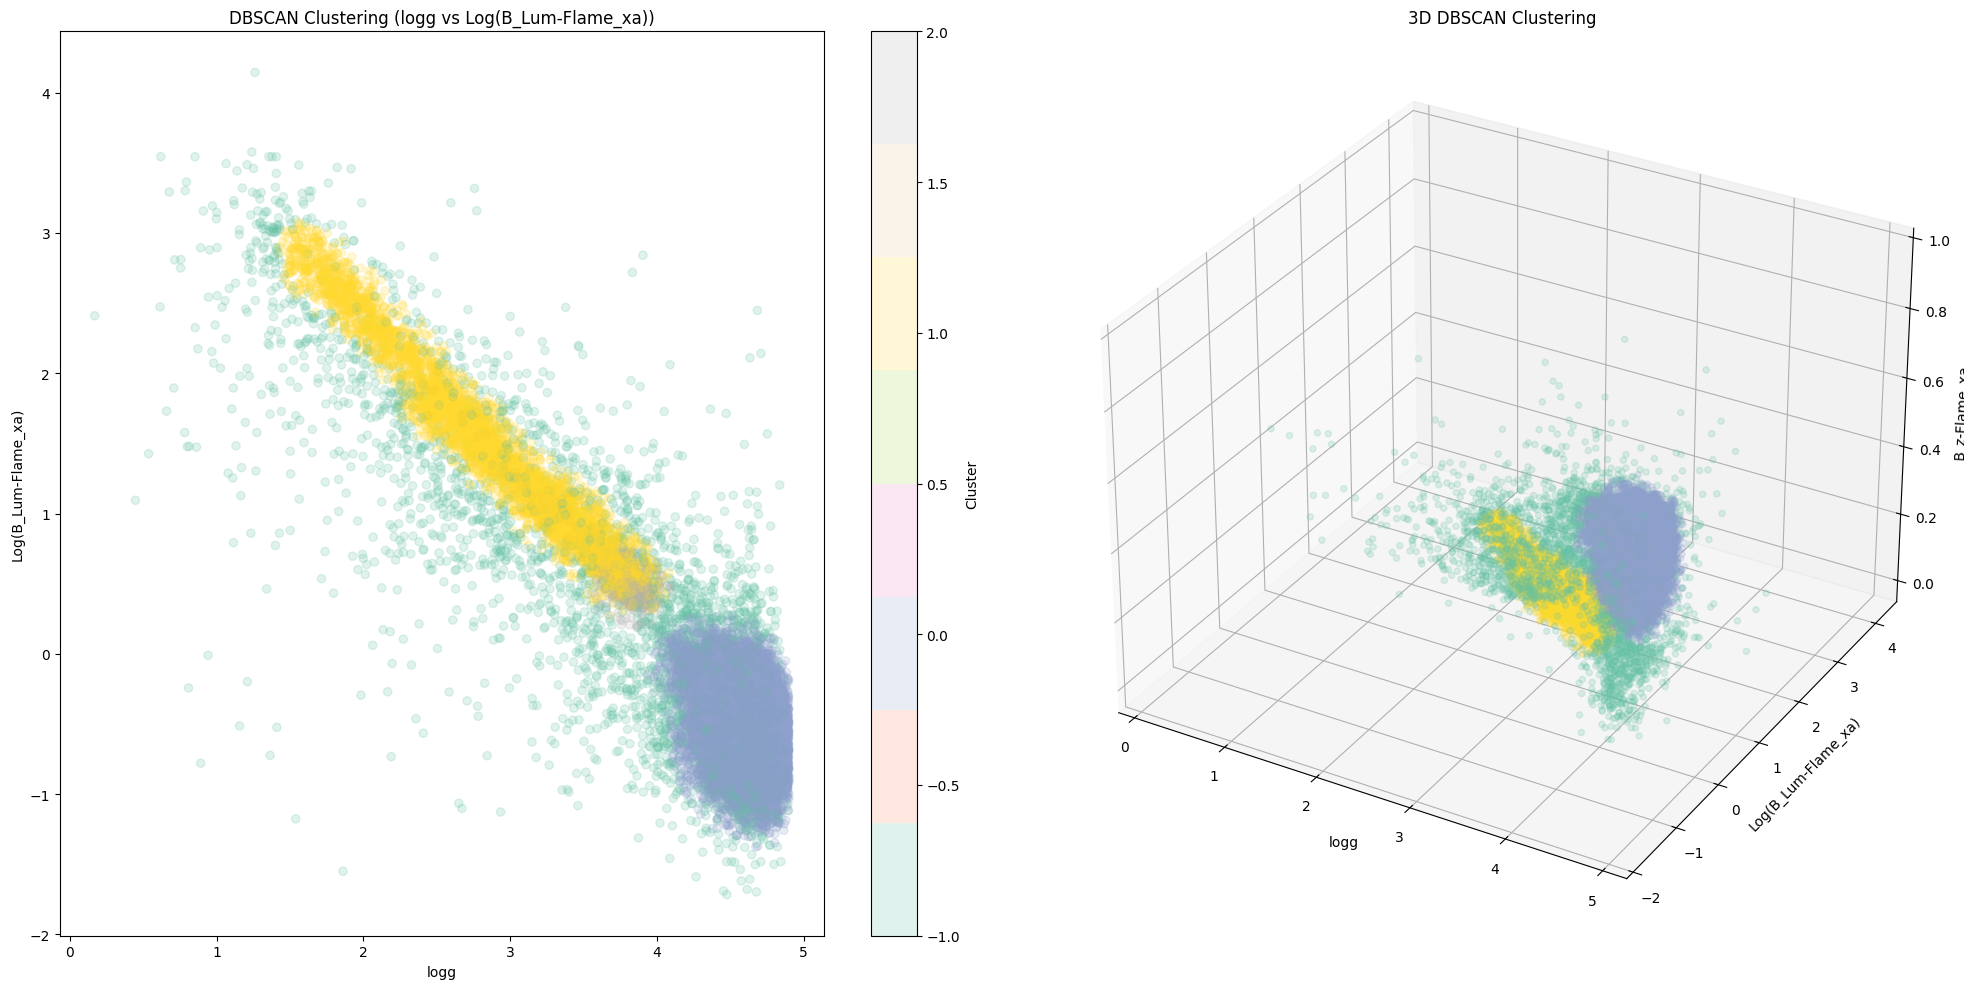

In [3]:
import os
os.environ["OMP_NUM_THREADS"] = "1"  # 设置OpenMP线程数为1，避免并行计算问题

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from mpl_toolkits.mplot3d import Axes3D

# 1. 数据加载与预处理
def load_and_preprocess(filepath):
    df = pd.read_csv(filepath)
    # 打印列名以确保没有问题
    print("Columns:", df.columns)
    
    # 选择关键物理参数
    features = ['logg', 'B_Lum-Flame_xa', 'B_z-Flame_xa']  # 确保这些列名正确
    df = df[features].dropna()
    
    # 对B_Lum-Flame_xa进行对数化处理
    df['log_B_Lum-Flame_xa'] = np.log10(df['B_Lum-Flame_xa'])
    
    # 物理范围过滤
    df = df[(df['logg'] > -100) & (df['logg'] < 100)]  # 合理温度范围
    
    # 打印数据的前几行，检查数据是否加载正确
    print(df.head())
    
    return df

# 2. 数据标准化
def standardize_data(df):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[['logg', 'log_B_Lum-Flame_xa', 'B_z-Flame_xa']])
    return X_scaled, scaler

# 3. 聚类分析
def perform_clustering(X_scaled):
    # DBSCAN聚类
    dbscan = DBSCAN(eps=0.25, min_samples=100)
    dbscan_labels = dbscan.fit_predict(X_scaled)
    
    print("DBSCAN labels:", np.unique(dbscan_labels))  # 打印DBSCAN标签，查看噪声点(-1)
    
    return dbscan_labels

# 4. 可视化函数
def plot_cluster_results(df, X_scaled, dbscan_labels):
    # 创建画布
    plt.figure(figsize=(20, 10))
    
    # 二维图 - DBSCAN结果
    plt.subplot(121)
    scatter = plt.scatter(df['logg'], df['log_B_Lum-Flame_xa'], c=dbscan_labels, cmap='Set2', alpha=0.2)
    plt.title('DBSCAN Clustering (logg vs Log(B_Lum-Flame_xa))')
    plt.xlabel('logg')
    plt.ylabel('Log(B_Lum-Flame_xa)')
    plt.colorbar(scatter, label='Cluster')
    
    # 三维图 - DBSCAN
    ax = plt.subplot(122, projection='3d')
    scatter = ax.scatter(df['logg'], df['log_B_Lum-Flame_xa'], df['B_z-Flame_xa'], 
                        c=dbscan_labels, cmap='Set2', alpha=0.2)
    ax.set_xlabel('logg')
    ax.set_ylabel('Log(B_Lum-Flame_xa)')
    ax.set_zlabel('B_z-Flame_xa')
    plt.title('3D DBSCAN Clustering')
    
    plt.tight_layout()
    plt.savefig('K2.png', dpi=300)  # 修改保存文件名
    plt.show()

# 主流程
def main(filepath):
    # 1. 加载完整的数据
    full_df = pd.read_csv(filepath)
    
    # 2. 对关键特征进行预处理
    df = full_df[['logg', 'B_Lum-Flame_xa', 'B_z-Flame_xa']].dropna()
    df['log_B_Lum-Flame_xa'] = np.log10(df['B_Lum-Flame_xa'])
    df = df[(df['logg'] > -100) & (df['logg'] < 100)]  # 物理范围过滤
    
    # 3. 数据标准化
    X_scaled, _ = standardize_data(df)
    
    # 4. 执行聚类
    dbscan_labels = perform_clustering(X_scaled)
    
    # 5. 将聚类标签添加到完整数据中
    full_df['dbscan_label'] = np.nan  # 初始化标签列为NaN
    full_df.loc[df.index, 'dbscan_label'] = dbscan_labels  # 将聚类标签填充到对应行
    
    # 6. 可视化结果
    plot_cluster_results(df, X_scaled, dbscan_labels)
    
    return full_df

if __name__ == "__main__":
    clustered_data = main("K删除列交叉完毕.csv")
    clustered_data.to_csv("样本V2/K主序test2.csv", index=False)